<a href="https://colab.research.google.com/github/tt28-cmd/Amazon-Sales-Analysis/blob/main/Amazon_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce Amazon Sales Performance Analysis


***Project Overview***

*Author* : Tamara Teodorović

*Date*

This project focuses on the analysis of Amazon sales records to uncover key businesses and operational trends.By using SQL for data manipulation and Python for analysis and visualization, raw transactional data is transformed  into strategic insights.

**Core Objectives**:

*Revenue Growth* - Identifying high-performing months, top-earning states(Maharashtra, Karnataka), and peak sales period

*Product Performance* - Identifying the best products and underperforming categories

*Customer & Business Segmentation* - Analyzing the distribution between B2B vs B2C transactions and their impact

*Operational Efficiency* - Order fulfillment status, courier efficiency, correlation between promotions and sales volume

*Data Integrity* - Implementing data cleaning and feature engineering(date-time conversion, handling null values) to ensure accurate results.



*Tools*: SQL, Python, Pandas, NumPy, Matplotlib, Seaborn.

*Environment*: Jupyter Notebook/Google Colab

In [ ]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading
The dataset is loaded directly from Google Drive using pandas.

There are a few observations:

**Date-Time Incompatibility**:

The Date column is identified as an object(text).For time-series analysis(monthly/yearly trends), it needs to be conversed to a proper datetime object

**Missing Values Identified**:

There were confirmed null values in several columns(Courier, Status, Currency, Amount, B2B)They needed to be removed to prevent distorted analysis


**Irrelevant Columns**:

Some columns contained zero non-values or any analytical value, so they are removed

**Categorical Opportunities**:

Several string columns(Status, Category, Fulfilment) were good for categorical grouping, but require standardization.


In [ ]:

# load dataset from Google Drive
path = "/content/drive/MyDrive/python_portfolio/project2/Amazon Sale Report.csv"

df = pd.read_csv(path, sep=",", encoding="latin1", header=0, low_memory=False)

# display first 5 rows
df.head()


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
print(df.columns)

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')


## Data Overview
Before cleaning the data, an initial inspection is performed to understand the structure and data types.

In [ ]:


# dataset structure and data types
df.info()

# statistical summary of numerical columns
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


---

---

## Data Cleaning
Done to ensure quality and reliability, for accurate analysis.

**Column Name Standardization**


Column names are standardized to ensure consistency and easier handling.

In [ ]:
# minimal column standardization
df.columns = df.columns.str.strip().str.lower().str.replace("_", "")
df.columns

Index(['index', 'order id', 'date', 'status', 'fulfilment', 'sales channel',
       'ship-service-level', 'style', 'sku', 'category', 'size', 'asin',
       'courier status', 'qty', 'currency', 'amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'b2b', 'fulfilled-by', 'unnamed: 22'],
      dtype='object')

**Standardization**

Column names were cleaned: converted to lowercase, original names were kept for readability and to maintain clarity.

In [ ]:
# convert date column to datetime with day-first
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
# invalid dates become NaT

# show first 5 rows to verify
df[["date"]].head()

# check number of invalid dates
invalid_dates = df["date"].isna().sum()
print("Number of invalid dates:", invalid_dates)

# remove rows with invalid dates
df = df.dropna(subset=["date"])

Number of invalid dates: 0


/tmp/ipykernel_1448/2626905499.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")


In [ ]:
print(df.columns)

Index(['index', 'order id', 'date', 'status', 'fulfilment', 'sales channel',
       'ship-service-level', 'style', 'sku', 'category', 'size', 'asin',
       'courier status', 'qty', 'currency', 'amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'b2b', 'fulfilled-by', 'unnamed: 22'],
      dtype='object')


**Data Cleaning - Quantity and Amount**

Rows with missing, invalid, or non-positive values in "qty" or "amount" were removed to ensure reliable analysis.A statistical summary was done to verify that all remaining values are valid.This includes count, mean, min, max, and standard deviation for each column.

In [ ]:
# convert "qty" and "amount" to numeric
df["qty"] = pd.to_numeric(df["qty"], errors="coerce")
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

# remove rows with missing or invalid values
df = df.dropna(subset=["qty", "amount"])

# remove rows with zero or negative quantities or amounts
df = df[(df["qty"]> 0)&(df["amount"]> 0)]

# check data
df[["qty", "amount"]].describe()

,qty,amount
count,113701.000000,113701.000000
mean,1.003852,663.164845
std,0.073385,269.538074
min,1.000000,199.000000
25%,1.000000,459.000000
50%,1.000000,625.000000
75%,1.000000,788.000000
max,8.000000,5584.000000


## Feature Engineering-Year and Month

Feature Engineering was performed to enable time-based analysis and improve revenue trends.

New columns "year" and "month" were extracted from the "date" column.This allows us to analyze sales trends over time, identify seasonal patterns, and perform year-over-year comparisons.

In [ ]:
# extract year and month from date column
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
# check
df[["date", "year", "month"]].head()

,date,year,month
1,2022-04-30,2022,4
2,2022-04-30,2022,4
4,2022-04-30,2022,4
5,2022-04-30,2022,4
6,2022-04-30,2022,4


In [ ]:

# ensure "amount" is numeric
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

# total revenue per year
revenue_by_year = df.groupby("year", as_index=False)["amount"].sum()
print(revenue_by_year)


   year      amount
0  2022  75402506.0


### Analysis

**Revenue Analysis**

Total revenue per year was calculated to identify annual growth trends and patterns.

In [ ]:
# group by SKU or product style and sum revenue
top_products = df.groupby("style", as_index=False)["amount"].sum()

# sort descending to get top sellers
top_products = top_products.sort_values(by="amount", ascending=False).head(10)

print(top_products)

        style     amount
860   JNE3797  2707151.0
301     J0230  1912416.0
1233   SET268  1291594.0
371     J0341  1217260.0
110     J0003   913344.0
552   JNE3405   823769.0
115     J0008   814328.0
1301   SET345   710098.0
1243   SET278   697379.0
1280   SET324   686995.0


**Top Products by Revenue**

This table shows the top 10 products that generated the most revenue, helping identify best-selling items and focus areas for sales strategy.

In [ ]:
# revenue by Sales Channel
channel_revenue = df.groupby("sales channel", as_index=False)["amount"].sum()
channel_revenue = channel_revenue.sort_values(by="amount", ascending=False)

print(channel_revenue)

  sales channel      amount
0     Amazon.in  75402506.0


**Revenue by Sales Channel**

This table presents total revenue from each sales channel.In this dataset, all transactions belong to a single channel, so only one row is shown.

In [ ]:
# revenue by B2B status
b2b_revenue = df.groupby("b2b", as_index=False)["amount"].sum()

print(b2b_revenue)

     b2b      amount
0  False  74822576.0
1   True    579930.0


### Vizualizations

## B2B vs Non-B2B Revenue
This analysis compares revenue from B2B and non-B2B transactions, showing which segment contributes more to total sales.

### Insights


*   **Non-B2B transactions (False)** contribute significantly more to the total revenue compared to **B2B transactions (True)**.
*   This indicates that the business primarily operates on a Business-to-Consumer model, with B2B sales being a very small fraction of the overall revenue.

 The vast majority of sales and revenue are generated through non-B2B customer transactions.

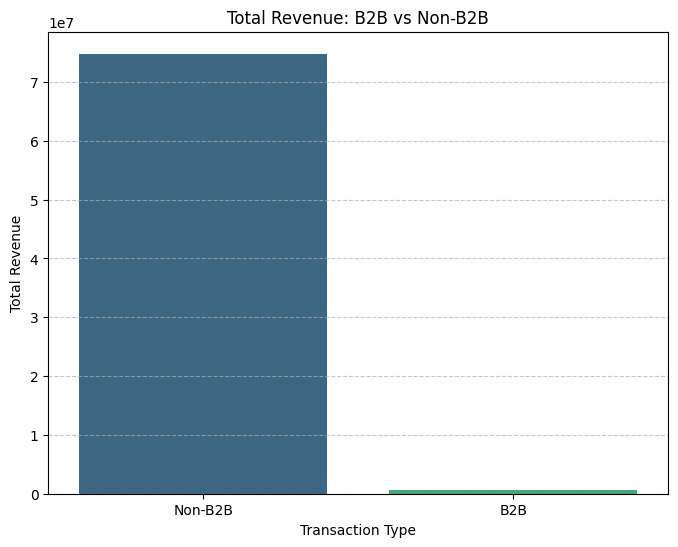

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='b2b', y='amount', hue='b2b', data=b2b_revenue, palette='viridis', legend=False)
plt.title('Total Revenue: B2B vs Non-B2B')
plt.xlabel('Transaction Type')
plt.ylabel('Total Revenue')
plt.xticks([0, 1], ['Non-B2B', 'B2B'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Yearly/Monthly Revenue Trends

**Monthly Revenue Trend**:
Tracks the total sales amount across different months.

*Purpose*- to identify patterns in consumers behaviour

*Observation*- There is a peak in the early months(April/May), followed by a decline towards the end of the year.That means that the marketing efforts or seasonal sales(like Summer Sales)drive volume .

**Yearly Revenue Trend**:
Compares the total revenue generated across different years(2022 vs 2024).

*Purpose*- To measure year over year growth and overall business scale.

*Observation*- Comparing the yearly totals allows us to see if the business is expanding or if external factors are stabilizing the revenue.

Current dataset is predominantly from 2022.This is why this visualization provides limited insight long-term, however, it helps summarize total annual revenue as a key performance indicator.

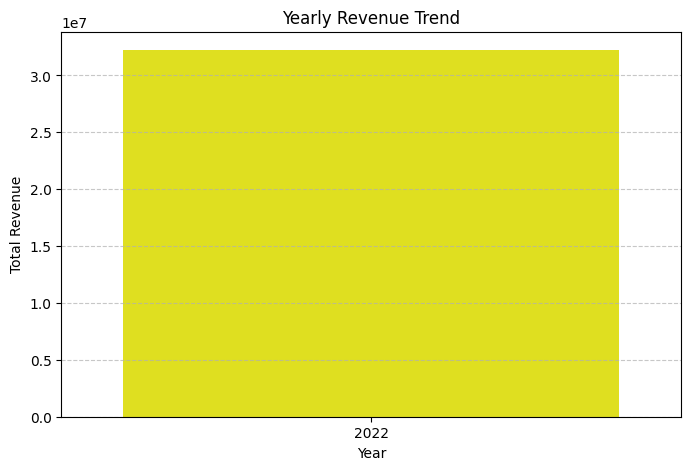

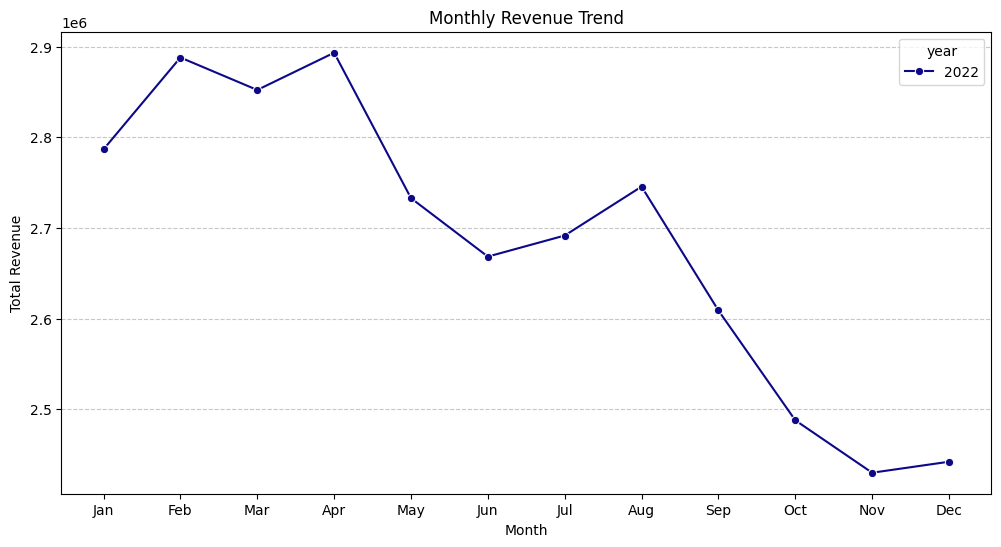

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Re-define df and apply essential preprocessing steps if not already done.
# This ensures the plotting cell can run independently if the kernel state is reset.

# Data Loading
path = "/content/drive/MyDrive/python_portfolio/project2/Amazon Sale Report.csv"
df = pd.read_csv(path, sep=",", encoding="latin1", header=0, low_memory=False)

# Column Name Standardization
df.columns = df.columns.str.strip().str.lower().str.replace("_", "")

# Date Conversion and Cleaning
# Specify date format to avoid UserWarning: Could not infer format
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%y", errors="coerce")
df = df.dropna(subset=["date"])

# Data Cleaning - Quantity and Amount
df["qty"] = pd.to_numeric(df["qty"], errors="coerce")
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
df = df.dropna(subset=["qty", "amount"])
df = df[(df["qty"] > 0) & (df["amount"] > 0)]

# Feature Engineering - Year and Month
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# Calculate yearly revenue
yearly_revenue = df.groupby('year')['amount'].sum().reset_index()

# Plot yearly revenue
plt.figure(figsize=(8, 5))
# Assign 'year' to 'hue' and set 'legend=False' to address FutureWarning
sns.barplot(x='year', y='amount', hue='year', data=yearly_revenue, palette=['yellow'], legend=False)
plt.title('Yearly Revenue Trend')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate monthly revenue
monthly_revenue = df.groupby(['year', 'month'])['amount'].sum().reset_index()

# Plot monthly revenue
plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='amount', hue='year', data=monthly_revenue, marker='o', palette='plasma')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Top Products by Revenue

**Product Performance**:

Understanding which products drive the most value for inventory managment and marketing focus.

A horizontal chart is used  to rank Top 10 SKUs, providing comparison of their contribution.

*Insight*- Top 5 products have a disproportionately high share of the total revenue.The business is dependent on these items.

*Recommendation* - Ensure these Top 10 never go out of stock, and they can be used in promotions to increase the sales of lower performing items.

/tmp/ipykernel_1448/3001700039.py:2: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='amount', y='style', hue='style', data=top_products, palette=['olive'], legend=False)


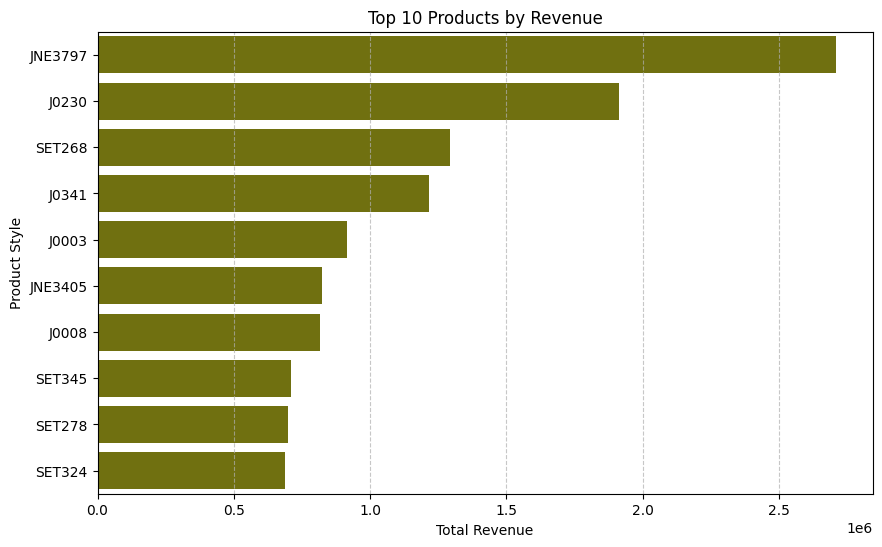

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='amount', y='style', hue='style', data=top_products, palette=['olive'], legend=False)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Style')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Revenue Distribution by Category

**Revenue Distribution by Category**:

Total revenue by product(Set, Kurta, Western Wear).Analyzing it helps business understand market demand.

*Observation*- Category Set dominates the revenue, followed by Kurta.
Western Dress is mid-tier category, and Blouse, Saree, Bottom represent smaller portions.

*Insight*- There is a strong preference for traditional or ethnic wear.

*Recommendation* - Products in high revenue categories should be prioritized and in stock, and mid categories should be explored for growth opportunities through marketing, diversification, or competitive pricing.

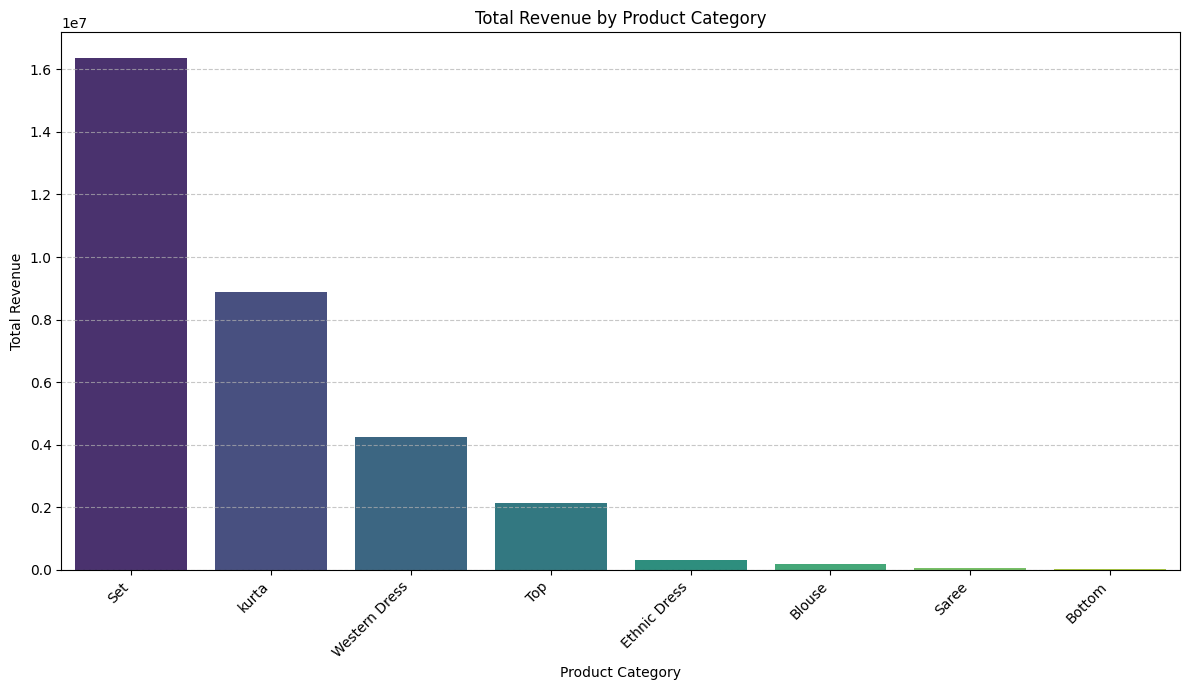

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Re-define df and apply essential preprocessing steps if not already done.
# This ensures the plotting cell can run independently if the kernel state is reset.

# Data Loading
path = "/content/drive/MyDrive/python_portfolio/project2/Amazon Sale Report.csv"
df = pd.read_csv(path, sep=",", encoding="latin1", header=0, low_memory=False)

# Column Name Standardization
df.columns = df.columns.str.strip().str.lower().str.replace("_", "")

# Date Conversion and Cleaning
# Specify date format to avoid UserWarning: Could not infer format
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%y", errors="coerce")
df = df.dropna(subset=["date"])

# Data Cleaning - Quantity and Amount
df["qty"] = pd.to_numeric(df["qty"], errors="coerce")
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
df = df.dropna(subset=["qty", "amount"])
df = df[(df["qty"] > 0) & (df["amount"] > 0)]

# Feature Engineering - Year and Month
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# Calculate total revenue per category
category_revenue = df.groupby('category')['amount'].sum().reset_index()

# Sort for better visualization
category_revenue = category_revenue.sort_values(by='amount', ascending=False)

# Create a bar chart for category revenue
plt.figure(figsize=(12, 7))
sns.barplot(x='category', y='amount', hue='category', data=category_revenue, palette='viridis', legend=False)
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sales Amount vs Promotion Status

In [ ]:
df['has_promotion'] = df['promotion-ids'].notna().astype(int)
df[['promotion-ids', 'has_promotion']].head()

,promotion-ids,has_promotion
29925,NaN,0
29926,NaN,0
29927,Amazon PLCC Free-Financing Universal Merchant ...,1
29928,Amazon PLCC Free-Financing Universal Merchant ...,1
29929,IN Core Free Shipping 2015/04/08 23-48-5-108,1


**Sales Amount and Promotion**

*Observation*:

Promotions influence sales performance, but their effectiveness may vary based on product type and timing.Differences between promotional and non-promotional are not significant, but difference still exists.

There should be the optimization of customer engagement and promotional strategies.

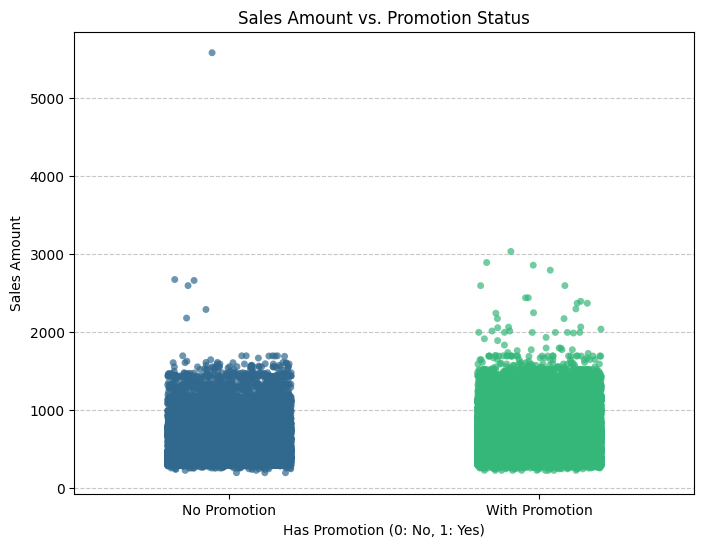

In [ ]:
plt.figure(figsize=(8, 6))
sns.stripplot(x='has_promotion', y='amount', data=df, jitter=0.2, hue='has_promotion', palette='viridis', alpha=0.7, legend=False)
plt.title('Sales Amount vs. Promotion Status')
plt.xlabel('Has Promotion (0: No, 1: Yes)')
plt.ylabel('Sales Amount')
plt.xticks([0, 1], ['No Promotion', 'With Promotion'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Returns and Cancellations

**Cancellations and Returns**


*Observations*:

A few products show significantly higher return and cancellation rates, showing possible problems with product quality, or logistics.

Identifying and addressing issues could help reduce losses.

In [ ]:
cancelled_returned_orders = df[df['status'].isin(['Cancelled', 'Shipped - Returned to Seller'])]

returns_cancellations = cancelled_returned_orders.groupby('sku').size().reset_index(name='num_returns')

returns_cancellations = returns_cancellations.sort_values(by='num_returns', ascending=False)

print(returns_cancellations.head())

                  sku  num_returns
598      JNE3405-KR-L           29
1475  SET268-KR-NP-XL           21
600      JNE3405-KR-S           18
1030     JNE3797-KR-L           17
1474   SET268-KR-NP-S           17


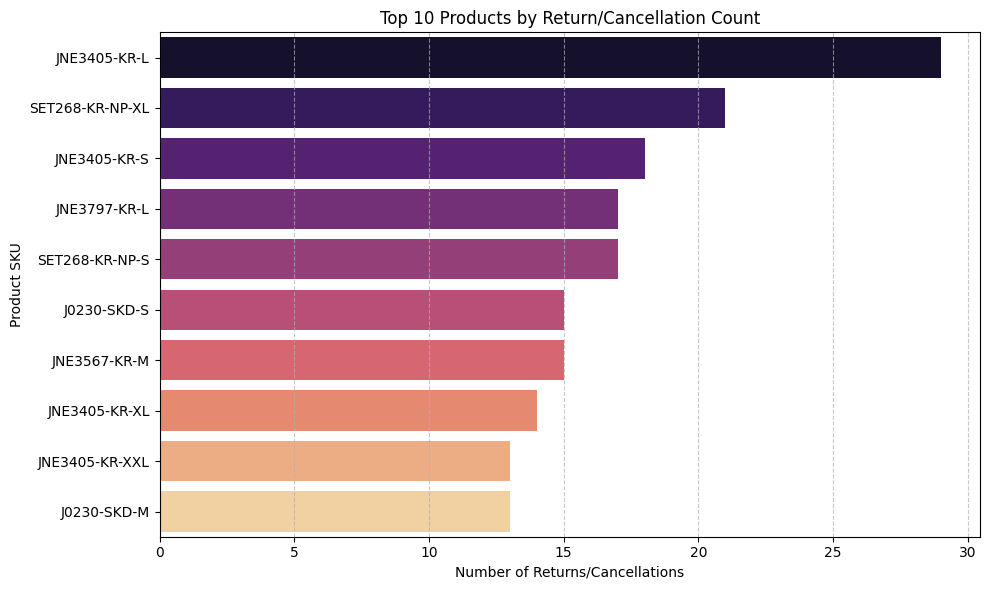

In [ ]:
top_10_returns_cancellations = returns_cancellations.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='num_returns', y='sku', hue='sku', data=top_10_returns_cancellations, palette='magma', legend=False)
plt.title('Top 10 Products by Return/Cancellation Count')
plt.xlabel('Number of Returns/Cancellations')
plt.ylabel('Product SKU')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### SQL

In [ ]:
import sqlite3
# create a connection to an sqlite database
conn = sqlite3.connect("AmazonSales.db")

# write the data to a sql table
df.to_sql("sales", conn, if_exists="replace", index=False)

print("SQL Database Created")

SQL Database Created


**Monthly Revenue**

Revenue shows consistent performance in the first half of the year, with a peak in April.

Stable monthly sales indicate a big demand.Fluctuations suggest that promotional events or seasonal changes at the beginning of the year drive higher engagement.

In [ ]:
# query 1 : monthly revenue trend(excluding cancellations)
query_revenue = """
SELECT Month, Year, SUM(Amount) as Total_Revenue
FROM sales
WHERE Status NOT IN ("Cancelled", "Shipped - Returned to Seller")
GROUP BY Year, Month
ORDER BY Year, Month;
"""

monthly_revenue_sql = pd.read_sql_query(query_revenue, conn)
display(monthly_revenue_sql.head())


,month,year,Total_Revenue
0,1,2022,2596656.0
1,2,2022,2671230.0
2,3,2022,2650353.0
3,4,2022,2708139.0
4,5,2022,2552950.0


**Top 10 States by Revenue**

Maharashtra is leading in the market, contributing significantly more than the rest, followed by Karnataka and Telangana.

Marketing and logistics should be prioritized in these regions.

In [ ]:
# query 2: top 10 states by revenue
query_states = """
SELECT
"ship-state" AS State,
SUM(Amount) AS Total_Revenue,
COUNT("Order ID") AS
Total_Orders
FROM sales
WHERE Status NOT IN ("Cancelled", "Shipped-Returned to Seller")
GROUP BY State
ORDER BY Total_Revenue DESC
LIMIT 10
"""

top_states_sql = pd.read_sql_query(query_states, conn)
display(top_states_sql)


,State,Total_Revenue,Total_Orders
0,MAHARASHTRA,5275550.0,8150
1,KARNATAKA,4166175.0,6387
2,UTTAR PRADESH,2700206.0,3826
3,TELANGANA,2582272.0,3909
4,TAMIL NADU,2533342.0,4151
5,DELHI,1696349.0,2504
6,KERALA,1384664.0,2216
7,WEST BENGAL,1380308.0,2196
8,ANDHRA PRADESH,1224024.0,1895
9,HARYANA,1107260.0,1537


**B2B Sales**

Business is almost entirely driven by Non-B2B (B2C, Business to Consumer) transactions, whisch is 99% of revenue.

But B2B still represents a massive opportunity for growth.Introducing corporate accounts could helpthis underdeveloped market.

In [ ]:
# query 3: B2B vs Non-B2B sales performannce
query_b2b = """
SELECT
B2B,
COUNT("Order ID") AS
Order_Count,
SUM(Amount) AS Total_Revenue,
(SUM(Amount)* 100.0 / (SELECT SUM(Amount) FROM sales))AS
Revenue_Percentage
FROM sales
GROUP BY B2B
"""

b2b_performance = pd.read_sql_query(query_b2b, conn)
display(b2b_performance)

,b2b,Order_Count,Total_Revenue,Revenue_Percentage
0,0,48487,32015000.0,99.338754
1,1,309,213107.0,0.661246


**Average Order Values**

The Set category brings high volume and highest AOV, followed by Saree and Western Dress.

Focus should be on them for high-margin campaigns.Customers are willing to spend more on these items per transaction, they should be the focus of Premium collections.

In [ ]:
#  query 4: average order value by category
query_aov = """
SELECT
Category,
AVG(Amount) AS
avg_order_value
FROM sales
WHERE Amount > 0
GROUP BY Category
ORDER BY avg_order_value
DESC;
"""

aov_sql = pd.read_sql_query(query_aov, conn)
display(aov_sql)


,category,avg_order_value
0,Set,850.732609
1,Saree,833.655738
2,Western Dress,782.342451
3,Ethnic Dress,728.699095
4,Blouse,558.819048
5,Top,538.149388
6,kurta,462.583598
7,Bottom,347.026549


### Summary

This project provided view of the Amazon sales dataset, combining Python analysis and SQL database.

**Key Takeaways**:

*Revenue: The business is reliant on the Set and Kurta categories.The SQL analysis confirmed that Set is top seller and holds the highest Average Order Value, which makes it the most profitable.

*Geographical Concentration: Maharashtra is the domiunant state for sales.This suggest a strong logistics and marketing foundation in Western India.

*Customer Segmentation: analysis of B2B vs Non-B2B(B2C) sales showed that 99% of revenue comes from individual consumers.B2B is left as a significant growth opportunity.

*Returns: Returns and Cancellations analysis identified specific high-risk SKUs that have disproportionately high return sales.Addressing the quality of these products could increase profit.

*Technical Integration: Project demonstrated a hybrid workflow : using Python for data cleaning and visualization, and SQL for structured business intelligence and data validation.


*Focus should be on diversifying the customer base(growing the B2B) and optimizing the inventory for high AOV categories like Set while investigating the logistics issue.*